# INTRODUCTION

We have done EDA on the dataset of Bank Call Data, resourced from Kaggle. Our Guide Renu Mam has helped us through whole project. All the work is done by using the pandas. We as team of 2 Members has worked on the dataset. Sumit Gill has worked on cleaning of Dataset, and the rest of the work was done by Gurlal Singh Gill, which included grouping and analysis.

# INTRODUCTION ABOUT DATASET

This dataset available on Kaggle is a popular dataset used for data analysis. The dataset includes various types of features such as client information (age, job, marital status, education), financial details (account balance, housing loan, personal loan, credit default), and campaign-related attributes (number of contacts, last contact duration, previous campaign outcomes).

# DATA OVERVIEW AND CLEANING

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel(r"C:\Users\Singh\Downloads\Excel files\Banking_Call_Data.xlsx")

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes,
    "Non-Null Count": df.count(),
    "Null Values": df.isnull().sum(),
    "Unknown Values": df.nunique()
})

summary

,Column Name,Data Type,Non-Null Count,Null Values,Unknown Values
age,age,int64,45211,0,77
job,job,object,45211,0,12
marital,marital,object,45211,0,3
education,education,object,45211,0,4
default,default,object,45211,0,2
balance,balance,int64,45211,0,7168
housing,housing,object,45211,0,2
loan,loan,object,45211,0,2
contact,contact,object,45211,0,3
day,day,int64,45211,0,31


In [6]:
cat_cols = ["job", "marital", "education", "contact", "poutcome"]
num_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]

# unknown → NaN
df[cat_cols] = df[cat_cols].replace("unknown", np.nan)

# categorical fill
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# numerical fill
df["age"] = df["age"].fillna(df["age"].mean())
df["balance"] = df["balance"].fillna(df["balance"].median())

for col in ["duration", "campaign", "previous"]:
    df[col] = df[col].fillna(df[col].median())

# pdays special
df["pdays"] = df["pdays"].replace(-1, np.nan)
df["pdays"] = df["pdays"].fillna(df["pdays"].median())

df["poutcome"] = df["poutcome"].fillna(df["poutcome"].mode()[0])

In [7]:
(df == "unknown").sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  int64  
 1   job        45211 non-null  object 
 2   marital    45211 non-null  object 
 3   education  45211 non-null  object 
 4   default    45211 non-null  object 
 5   balance    45211 non-null  int64  
 6   housing    45211 non-null  object 
 7   loan       45211 non-null  object 
 8   contact    45211 non-null  object 
 9   day        45211 non-null  int64  
 10  month      45211 non-null  object 
 11  duration   45211 non-null  int64  
 12  campaign   45211 non-null  int64  
 13  pdays      45211 non-null  float64
 14  previous   45211 non-null  int64  
 15  poutcome   45211 non-null  object 
 16  y          45211 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 5.9+ MB


#  ANALYSING OVERALL SUCCESS RATE OF CAMPAIGN

In [32]:
df_success=df['y'].value_counts(normalize=True) * 100

In [33]:
df_success

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

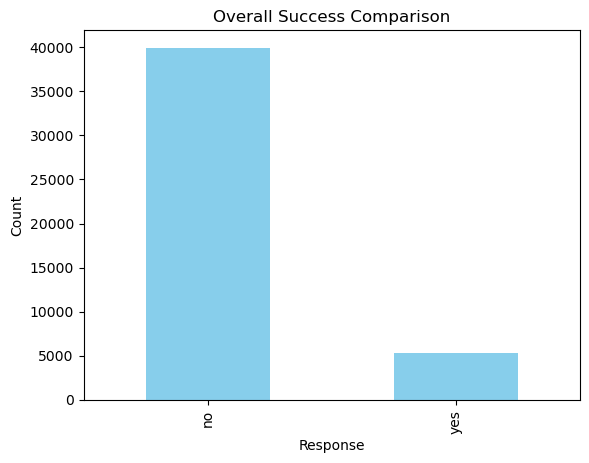

In [30]:
df_success.plot(kind='bar', color='skyblue')

import matplotlib.pyplot as plt
plt.title('Overall Success Comparison')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()

# IT CLEARLY SHOWS THAT CAMPAIGN HAD NEARLY 12% OF SUCCESS RATE

# ANALYSING CALL DURATION IMPACT

In [90]:
df_duration=df.groupby('y')['duration'].mean()

In [91]:
df_duration

y
no     221.182806
yes    537.294574
Name: duration, dtype: float64

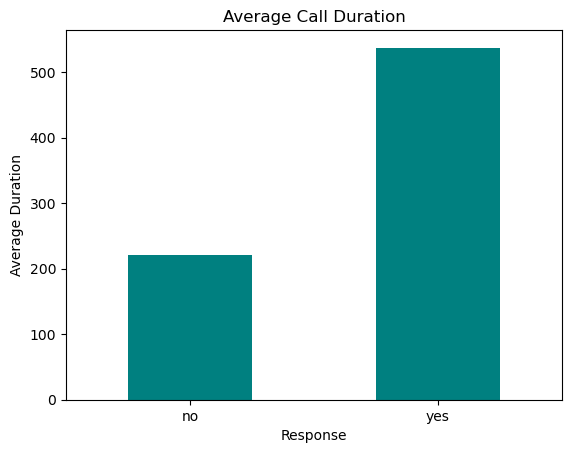

In [92]:
import matplotlib.pyplot as plt

df_duration.plot(kind='bar', color='teal')

plt.title('Average Call Duration')
plt.xlabel('Response')
plt.ylabel('Average Duration')
plt.xticks(rotation=0)
plt.show()

# HAVING A LONG DURATION SHOWS PERSON MORE LIKELY TO BE ENROLLED IN THE CAMPAIGN

# ANALYSIS OF IMPACT OF BANK BALANCE

In [38]:
df_balance=df.groupby('y')['balance'].mean()

In [39]:
df_balance

y
no     1303.714969
yes    1804.267915
Name: balance, dtype: float64

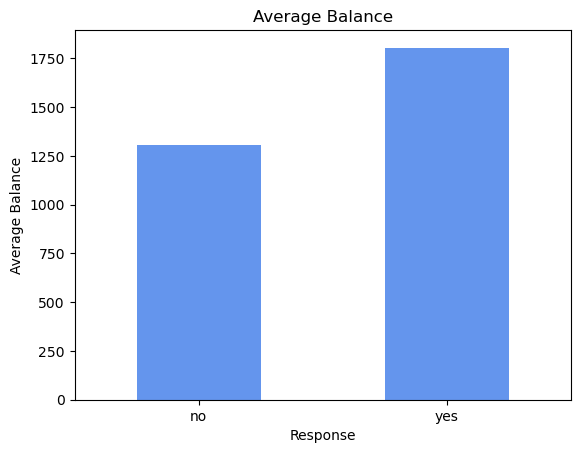

In [41]:
import matplotlib.pyplot as plt

df_balance.plot(kind='bar', color='cornflowerblue')

plt.title('Average Balance')
plt.xlabel('Response')
plt.ylabel('Average Balance')
plt.xticks(rotation=0)
plt.show()

# HAVING A GOOD BALANCE IN ACCOUNT INCREASES CHANCE TO BE ENROLLED IN THE CAMPAIGN

# EFFECT OF RUNNING LOANS 

In [45]:
df_loan=df.groupby(['housing','loan'])['y'].value_counts(normalize=True)*100

In [46]:
df_loan

housing  loan  y  
no       no    no     81.777494
               yes    18.222506
         yes   no     92.387904
               yes     7.612096
yes      no    no     91.956846
               yes     8.043154
         yes   no     93.931761
               yes     6.068239
Name: proportion, dtype: float64

In [47]:
df_loan = df_loan.reset_index(name='percentage')
df_loan

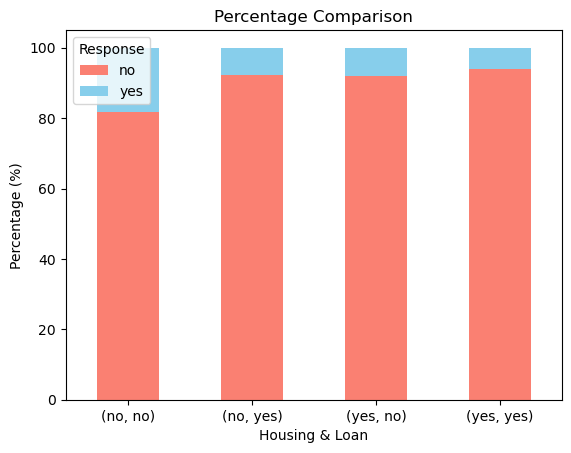

In [49]:
import matplotlib.pyplot as plt

# Pivot for plotting
df_plot = df_loan.pivot_table(index=['housing', 'loan'], columns='y', values='percentage')

# Plot
df_plot.plot(kind='bar', stacked=True, color=['salmon','skyblue'])

plt.title('Percentage Comparison')
plt.xlabel('Housing & Loan')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.show()

# PERSON NOT HAVING A RUNNING LOAN ARE MORE LIKELY TO BE ENROLLED IN CAMPAIGN

# IMPACT OF BEING A LOAN DEFAULTER

In [51]:
df_default=df.groupby('default')['y'].value_counts(normalize=True)*100

In [52]:
df_default

default  y  
no       no     88.203892
         yes    11.796108
yes      no     93.619632
         yes     6.380368
Name: proportion, dtype: float64

In [53]:
df_default = df_default.reset_index(name='percentage')

In [54]:
df_plot = df_default.pivot(index='default', columns='y', values='percentage')

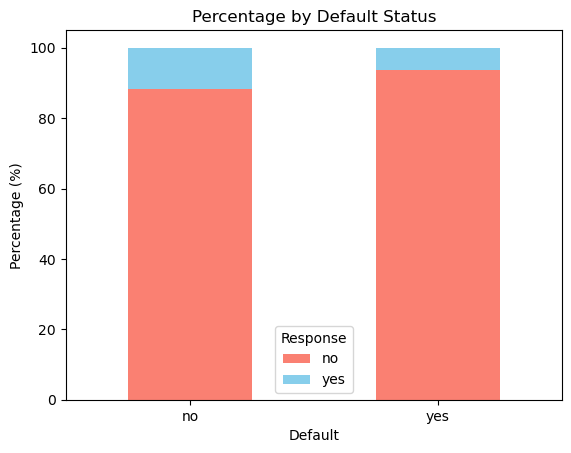

In [56]:
import matplotlib.pyplot as plt

df_plot.plot(kind='bar', stacked=True, color=['salmon', 'skyblue'])

plt.title('Percentage by Default Status')
plt.xlabel('Default')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.show()

# BEING A LOAN DEFAULTER REDUCES CHANCES FOR NOT BE ENROLLED IN CAMPAIGN BY ALMOST 50% 

# AGE AS DECIDING FACTOR

In [58]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 35, 60, 100],
    labels=['Young Adult', 'Adult', 'Senior']
)

In [61]:
age_group= df.groupby('age_group')['y'].value_counts(normalize=True)*100

C:\Users\Singh\AppData\Local\Temp\ipykernel_2624\771076666.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group= df.groupby('age_group')['y'].value_counts(normalize=True)*100


In [62]:
age_group

age_group    y  
Young Adult  no     87.084936
             yes    12.915064
Adult        no     90.418941
             yes     9.581059
Senior       no     57.744108
             yes    42.255892
Name: proportion, dtype: float64

In [63]:
age_group = age_group.reset_index(name='percentage')

In [64]:
df_plot = age_group.pivot(index='age_group', columns='y', values='percentage')

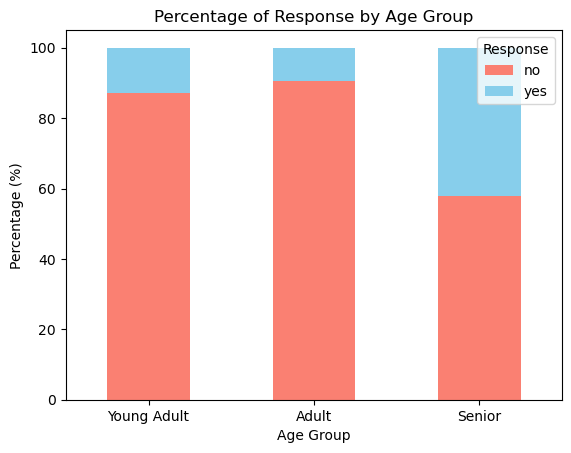

In [66]:
import matplotlib.pyplot as plt

df_plot.plot(kind='bar', stacked=True, color=['salmon', 'skyblue'])

plt.title('Percentage of Response by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.show()

# SENIOR PERSONS ARE MUCH LIKELY TO BE ENROLLED IN CAMPAIGN

# IMPACT OF THE PROFESSIONAL ROLES

In [68]:
df_profession=df.groupby('job')['y'].value_counts(normalize=True)*100

In [69]:
df_profession

job            y  
admin.         no     87.797331
               yes    12.202669
blue-collar    no     92.594810
               yes     7.405190
entrepreneur   no     91.728312
               yes     8.271688
housemaid      no     91.209677
               yes     8.790323
management     no     86.244449
               yes    13.755551
retired        no     77.208481
               yes    22.791519
self-employed  no     88.157061
               yes    11.842939
services       no     91.116996
               yes     8.883004
student        no     71.321962
               yes    28.678038
technician     no     88.943004
               yes    11.056996
unemployed     no     84.497314
               yes    15.502686
Name: proportion, dtype: float64

In [70]:
df_profession = df_profession.reset_index(name='percentage')

In [71]:
df_plot = df_profession.pivot(index='job', columns='y', values='percentage')

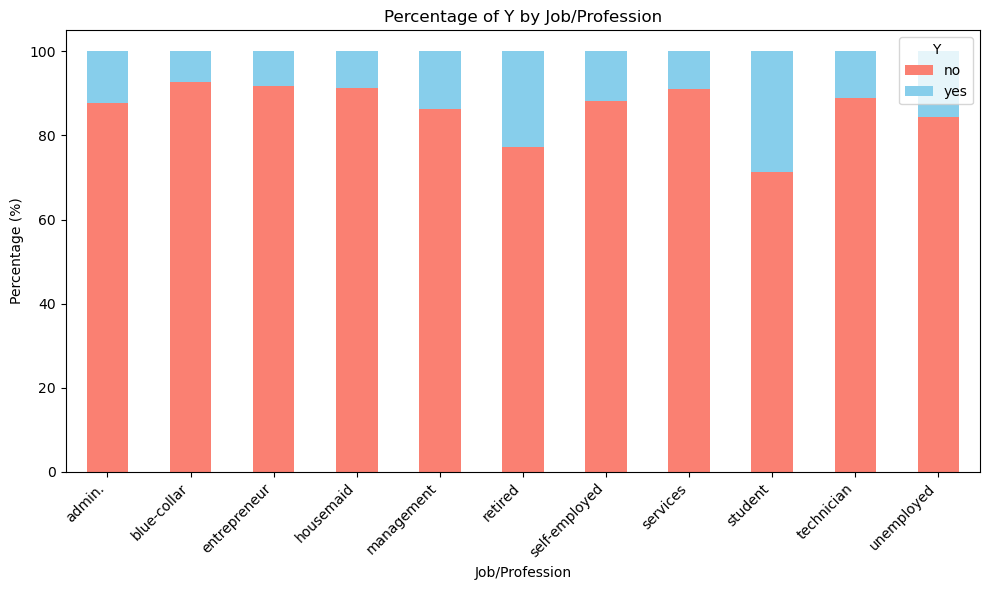

In [72]:
import matplotlib.pyplot as plt

df_plot.plot(kind='bar', stacked=True, color=['salmon', 'skyblue'], figsize=(10,6))

plt.title('Percentage of Response by Job/Profession')
plt.xlabel('Job/Profession')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Response')
plt.tight_layout()
plt.show()

# PROFESSIONALY STUDENTS AND RETIRED ARE SHOWING MORE INTEREST IN THE CAMPAIGN

# MARITAL STATUS PLAYING A FACTOR?

In [93]:
df_marital_status=df.groupby('marital')['y'].value_counts(normalize=True)*100

In [94]:
df_marital_status

marital   y  
divorced  no     88.054542
          yes    11.945458
married   no     89.876534
          yes    10.123466
single    no     85.050821
          yes    14.949179
Name: proportion, dtype: float64

In [95]:
df_marital_status=df_marital_status.reset_index(name='percentage')

In [96]:
df_marital_status

,marital,y,percentage
0,divorced,no,88.054542
1,divorced,yes,11.945458
2,married,no,89.876534
3,married,yes,10.123466
4,single,no,85.050821
5,single,yes,14.949179


In [97]:
df_plot = df_marital_status.pivot(index='marital', columns='y', values='percentage')

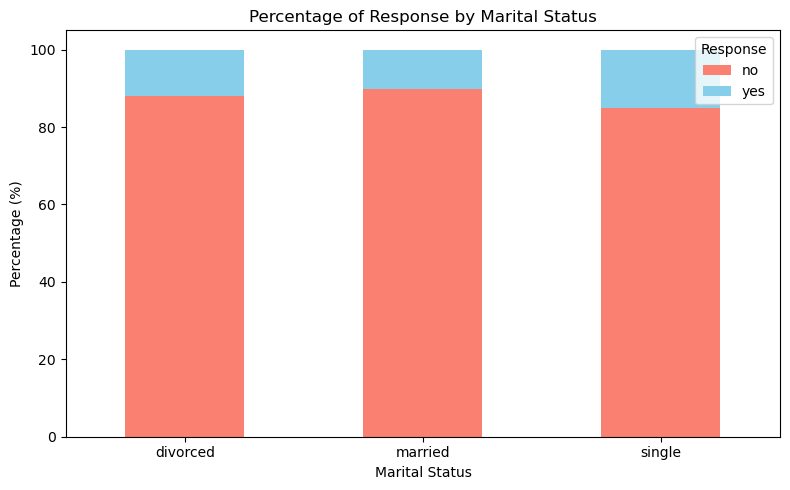

In [98]:
import matplotlib.pyplot as plt

df_plot.plot(kind='bar', stacked=True, color=['salmon', 'skyblue'], figsize=(8,5))

plt.title('Percentage of Response by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.tight_layout()
plt.show()

# MARITAL STATUS IS PLAYING A FACTOR IN DECIDING 
# IT SHOWS EITHER SINGLE OR DIVORCED PERSON ARE SHOWING MORE INTEREST RATHER THEN MARRIED

# ROLE OF EDUCATION 

In [79]:
df_education=df.groupby('education')['y'].value_counts(normalize=True)*100

In [80]:
df_education

education  y  
primary    no     91.373522
           yes     8.626478
secondary  no     89.217447
           yes    10.782553
tertiary   no     84.993610
           yes    15.006390
Name: proportion, dtype: float64

In [81]:
df_education=df_education.reset_index(name='percentage')

In [82]:
df_education

,education,y,percentage
0,primary,no,91.373522
1,primary,yes,8.626478
2,secondary,no,89.217447
3,secondary,yes,10.782553
4,tertiary,no,84.993610
5,tertiary,yes,15.006390


In [84]:
df_plot=df_education.pivot(index='education',columns='y',values='percentage')

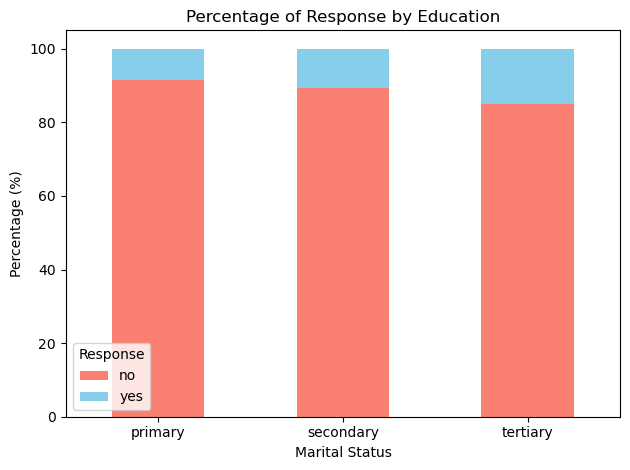

In [86]:
df_plot.plot(kind='bar',stacked=True, color=['salmon', 'skyblue'])
plt.title('Percentage of Response by Education')
plt.xlabel('Marital Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.tight_layout()
plt.show()

# EDUCATION IS PLAYING A SIGNIFICANT ROLE 
# BEING MORE EDUCATED SHOWS POSITIVE SIGNS OF BEING ENROLLED IN CAMPAIGN

# Key Insights 

# Conversion rate is low.
# Previous campaign success strongly influences future conversion
# Customers without loans show better response
# Balance has mild positive influence
# Duration is highly correlated but unusable for prediction